<div style="text-align: center; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 24px;">
    <h1>
        SINAIS E SISTEMAS EM TEMPO CONTÍNUO: TRANSFORMADA DE LAPLACE
    </h1>
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h2>
        Introdução
    </h2>
    <p style="text-indent: 2em;">
        Nos notebooks anteriores, foi visto como no regime temporal, a saída y(t) de um sistema LCIT pode ser obtida decompondo a entrada x(t) numa série de componentes impulsivos e somando as respostas do sistema a cada um desses componentes. Como você provavelmente percebeu, tal processo é computacionalmente complexo, ilustrando a dificuldade de se trabalhar com EDOs no tempo. Já no domínio de Fourier, x(t) é decomposto em um espectro de frequências, que facilita a obtenção da resposta do sistema, porém com algumas ressalvas (ver a seção 3.3 do notebook 2). Buscamos, então, uma ferramenta que seja mais flexível que a transformada de Fourier no sentido de resolução de sistemas lineares, mas que retenha sua característica de facilitar a análise de sistemas LCIT. Para suprir essa necessidade, estendemos nossa frequência jω, restrita ao eixo imaginário, para a frequência complexa s = σ + jω situada em todo o plano complexo, ou no presente contexto, no domínio de <b>Laplace</b>:
</div>

$$
Transformada\;de\;Laplace:
$$
$$
\mathcal{L} \{x(t)\} = X(s) = \int_{-\infty}^{\infty} x(t) e^{-st} dt
$$
$$
Transformada\;de\;Laplace\;Inversa:
$$
$$
\mathcal{L}^{-1} \{X(s)\} = x(t) = \frac{1}{j2\pi}\int_{c -j\infty}^{c + j\infty} X(s) e^{st} dt .
$$

<div style="
    font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif;
    font-size: 20px;
">

<h2>Sumário</h2>

<div style="
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 40px;
    align-items: start;
">
    <div>
        <h4>1 - Fundamentos da Transformada de Laplace</h4>
        <ul>
            <li>1.1 - Região de Convergência</li>
            <li>1.2 - Exemplo de Cálculo da Transformada Direta</li>
            <li>1.3 - Exemplo de Cálculo da Transformada Inversa</li>
            <li>1.4 - Propriedades da Transformada de Laplace</li>
        </ul>
        <h4>Apêndice: Script de Transformada de Laplace de um Sinal</h4>
    </div>
    <div>
        <h4>2 - Resolvendo EDO's com a Transformada de Laplace</h4>
        <ul>
            <li>2.1 - Exemplo</li>
            <li>2.2 - Função de Transferência</li>
            <li>2.3 - Estabilidade e Sistema Inverso</li>
            <li>3.4 - Energia de Sinais</li>
        </ul>
    </div>
</div>
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h2>
        1 - Fundamentos da Transformada de Laplace
    </h2>
    <h4>
        1.1 - Região de Convergência
    </h4>
    <p style="text-indent: 2em;">
        A resolução integral da transformada de laplace difere da resolução da integral de Fourier, no sentido em que deve haver uma cautela maior acerca da convergência da integral. “A Região de Convergência (RDC) é o conjunto de valores de s para os quais a integral de Laplace converge” (Eduardo S. Tognetti aula 11, slide 9). À luz disso, é interessante apontar que a transformada de Laplace pode ser vista como uma generalização da transformada de Fourier, indo do eixo imaginário (jω) para todo o plano complexo, tal que X(jω) = X(s)|<sub>s = jω</sub> quando a RDC inclui o eixo jω. Em troca do trabalho extra de determinar a RDC, surge a vantagem de que a transformada de Laplace pode existir para um determinado sinal mesmo quando a transformada de Fourier não existir para esse mesmo sinal.
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        1.2 - Exemplo de Cálculo da Transformada Direta
    </h4>
    <p style="text-indent: 2em;">
        Vamos obter a transformada de laplace do sinal e<sup>-at</sup> u(t), onde a ∈ ℝ<sup>+</sup>.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [2]:
t, a, s, T = sp.symbols('t, a, s, T')

x = sp.exp(-a*t) * sp.Heaviside(t)
nucleo_da_transformada = sp.exp(-s*t)

integrando = x * nucleo_da_transformada
transformada = sp.Integral(integrando, (t, -sp.oo, sp.oo))

display(transformada) # Lembrando que o degrau u(t) é representado por theta no sympy

Integral(exp(-a*t)*exp(-s*t)*Heaviside(t), (t, -oo, oo))

In [3]:
# Resolvendo a integral acima:
transformada = sp.Integral(sp.exp(-t*(s+a)), (t, 0, T))
transformada_lim = sp.Limit(transformada, T, sp.oo)
transformada = sp.Limit(transformada.doit().args[0][0], T, sp.oo)

display(sp.Eq(transformada_lim, transformada))

Eq(Limit(Integral(exp(-t*(a + s)), (t, 0, T)), T, oo, dir='-'), Limit(1/(a + s) - exp(-T*(a + s))/(a + s), T, oo, dir='-'))

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    Repare na exponensial dentro dos parênteses no lado direito da igualdade. Para analisar a convergência deste termo, convém separar a exponencial em suas partes reais e imaginárias: e<sup>-(a+σ)T</sup>e<sup>-jωT</sup> (onde s = σ + jω). Dessa forma, fica evidente que se o expoente real for positivo, o resultado do limite tenderá ao infinito, logo a integral irá divergir. Isso impõe a condição σ = Re{s} > -a, sendo essa a região de convergência para nossa transformada. Finalmente:
</div>

$$
X(s) = \frac{1}{s + a} ~~~~~~~~ (Re\{s\} > -a)
$$

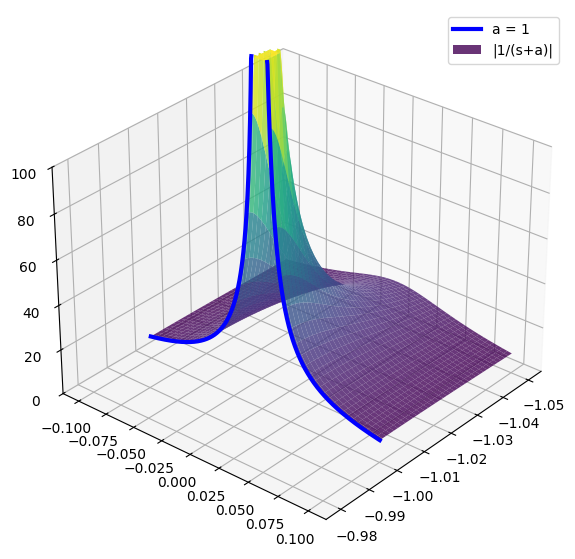

In [4]:
sigma = np.linspace(-1.05, -0.98, 1000)
omega = np.linspace(-0.1, 0.1, 1000)
re, im = np.meshgrid(sigma, omega)
a = 1

z = lambda x,y: 1/np.sqrt((x + a)**2 + y**2)
Z = z(re, im)
Z = np.clip(Z, None, 150)
Z = np.where(re > -a, np.nan, Z)

t = np.linspace(-0.1, 0.1, 1000)
u = -a
v = t
v = np.where((v < 0.0065) & (v > -0.0065), np.nan, v)
w = 1/np.sqrt(t**2)
w = np.clip(w, None, 150)

fig = plt.figure(figsize = (7,7))
ax = fig.add_subplot(projection = '3d') #adiciona axe

ax.plot(u, v, w, linewidth=3, color='blue', label='a = 1', zorder=10)
ax.plot_surface(re, im, Z, alpha=0.8, cmap='viridis', label='|1/(s+a)|', zorder=1)
ax.legend()
ax.set_zlim3d(0, 100)

ax.view_init(30, 40)
plt.show()

  <div style="text-align: right; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 14px;">
    Plot da magnitude de 1/(s+a), com a = 1. A curva azul indica o limite da RDC. 
  </div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <p style="text-indent: 2em;">
        Características da RDC:
        <ul>
            <li>A RDC consiste em faixas paralelas ao eixo jω.</li>
            <li>Para uma transformada de Laplace racional, a RDC não contém os pontos nos quais o denominador é zerado (pólos).</li>
            <li>Se x(t) for um sinal absolutamente integrável de suporte finito, a RDC de X(s) será todo o plano complexo.</li>
            <li>Se x(t) for um sinal lateral definido à direita (x(t) = 0 para todo t < t<sub>0</sub>), a RDC de X(s) será à direita (estritamente maior) do maior polo de X(s).</li>
            <li>Se x(t) for um sinal definido à esquerda, a RDC será à esquerda do menor polo de X(s).</li>
            <li>Um sinal X(s) pode corresponder a vários sinais no tempo, dependendo da RDC. Devido a isso e ao fato de os sinais de interesse prático serem causais, há o incentivo de usar da transformada de Laplace unilateral, a qual dispensa a especificação da RDC e é restrita a sinais causais:
        </ul>
</div>

$$
\mathcal{L} \{x(t)\} = X(s) = \int_{0^{-}}^{\infty} x(t) e^{-jst} dt
$$

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        1.3 - Exemplo de Cálculo da Transformada Inversa
    </h4>
    <p style="text-indent: 2em;">
        Geralmente, o cálculo da transformada inversa é feito com o auxílio de uma tabela de transformadas. O motivo disso, é a dificuldade de resolver a integral da transformada inversa para sinais comuns, sem ferramentas vistas em um curso de variável complexa. Como os sinais na frequência são, comumente, funções racionais, o procedimento geral de obtenção do sinal correspondente no tempo é feito decompondo o sinal na frequência em frações parciais, sendo o sinal no tempo a soma das transformadas das parcelas na frequência (linearidade).
    <p style="text-indent: 2em;">
        A partir disso, considere o sinal X(s) = (s + 2)/[s<sup>2</sup>(s + 1)]. Assumindo a causalidade do sinal x(t) no tempo e que a convergência da transformada inversa é garantida, vamos obter x(t):
</div>

In [5]:
t, s, X, x = sp.symbols('t, s, X(s), x(t)', positive=True) # Assumindo t positivo para forçar a causalidade na solução final
X_s = (s + 2) / (s**2*(s + 1))
display(sp.Eq(X, X_s))

#  Decompondo em frações parciais:
X_s = sp.apart(X_s)
display(sp.Eq(X, X_s))

#Obtendo a transformada inversa:
x_t = sp.inverse_laplace_transform(X_s, s, t)
display(sp.Eq(x, x_t))

Eq(X(s), (s + 2)/(s**2*(s + 1)))

Eq(X(s), 1/(s + 1) - 1/s + 2/s**2)

Eq(x(t), 2*t - 1 + exp(-t))

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        1.4 - Propriedades da Transformada de Laplace
    </h4>
    <p style="text-indent: 2em;">
    	As propriedades da transformada de Laplace são similares às da transformada de Fourier e têm consequências importantes na aplicação a sistemas LCIT. Seja x<sub>n</sub>(t) um sinal no tempo tal que x<sub>n</sub>(t) ⇔ X<sub>n</sub>(ω) e a<sub>n</sub> constante. Resumidamente, as propriedades da transformada de Laplace são:
        <ul>
            <li>Linearidade:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; a<sub>1</sub>x<sub>1</sub>(t) + a<sub>2</sub>x<sub>2</sub>(t) ⇔ a<sub>1</sub>X<sub>1</sub>(s) + a<sub>2</sub>X<sub>2</sub>(s).</li>
            <li>Deslocamento no Tempo:	&ensp;&emsp;&emsp;&emsp;&emsp; x(t − t<sub>0</sub>)u(t − t<sub>0</sub>) ⇔ e<sup>−st<sub>0</sub></sup>X(s), t<sub>0</sub> > 0.</li>
            <li>Deslocamento na Frequência:	&nbsp;&ensp;&emsp;&emsp; e<sup>s<sub>0</sub>t</sup>x(t) ⇔ X(s − s<sub>0</sub>)</li>
            <li>Diferenciação no Tempo:&emsp;&emsp;&emsp;&emsp;&emsp; d<sup>n</sup>x/dt<sup>n</sup> ⇔ s<sup>n</sup>X(s) − s<sup>n−1</sup>x(0<sup>−</sup>) − s<sup>n−2</sup>x′(0<sup>−</sup>) − · · · − x<sup>(n−1)</sup>(0<sup>−</sup>).</li>
            <li>Integração no Tempo:&nbsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; ∫<sub>0<sup>-</sup></sub><sup>t</sup>  x(𝜏)d𝜏 ⇔ X(s)/s.</li>
            <li>Escalonamento no Tempo:&nbsp;&emsp;&emsp;&emsp;&emsp; x(at) ⇔ (1/a) X(s/a)</li>
            <li>Convolução no Tempo:&nbsp;&ensp;&emsp;&emsp;&emsp;&emsp;&emsp; x<sub>1</sub>(t) ∗ x<sub>2</sub>(t) ⇔ X<sub>1</sub>(s)X<sub>2</sub>(s)</li>
            <li>Convolução na Frequência:&emsp;&emsp;&emsp;&emsp; x<sub>1</sub>(t)x<sub>2</sub>(t) ⇔ (1/2πj) X<sub>1</sub>(s) * X<sub>2</sub>(s)</li>
            <li>Conjugado:&ensp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; x<sup>*</sup>(t) ⇔ X<sup>*</sup>(s<sup>*</sup>) &emsp;&emsp;&emsp;&emsp;(Se s<sub>0</sub> for um polo de X(s) então s<sub>0</sub><sup>*</sup> também será).</li>
        </ul>
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h2>
        2 - Resolvendo EDO's com a Transformada de Laplace
    </h2>
    <h4>
        2.1 - Exemplo
    </h4>
    <p style="text-indent: 2em;">
        A vantagem principal da se trabalhar no domínio de Laplace, é que EDOs no tempo são convertidas em equações algébricas na frequência. O passo-a-passo difícil de obtenção da resposta total de um sistema LCIT visto no primeiro notebook, é simplificado à aplicação da transformada à EDO; uso das propriedades de linearidade e diferenciação para aplicar as condições iniciais; isolamento de Y(s) e finalmente aplicação da transformada inversa para chegar-se a y(t).
    <p style="text-indent: 2em;">
        Vamos resolver a EDO abaixo (Exemplo 4.10 - Lathi), com condições iniciais y(0<sup>−</sup>) = 2 e y'(0<sup>−</sup>) = 1:
</div>

$$
\frac{d^{2}y}{dt^{2}}
+ 4\frac{dy}{dt} 
+ 10y(t)
= e^{-4t}u(t),
$$

In [6]:
s, t, Y, y = sp.symbols('s, t, Y(s), y(t)')

# Aplicando a transformada de Laplace nos dois lados, obtemos s^2 Y(s) − sy(0−) − y'(0−) + 4[sY(s) − y(0−)] + 10Y(s) = 1/(s + 4)
# Substituindo as condições iniciais:
LHS = s**2*Y - 2*s -1 + 4*s*Y - 8 + 10*Y
RHS = 1 / (s + 4)
EDO_L = sp.Eq(LHS, RHS)
display(EDO_L)

# Isolando os termos Y(s) no lado direito e dividindo o lado esquerdo pelos fatores de Y(s):
LHS = Y
RHS = (2*s + 9) / (s**2 + 4*s + 10) + 1 / ((s+4)*(s**2 + 4*s + 10))
EDO_L = sp.Eq(LHS, RHS)
display(EDO_L)

# Realizando a transformada inversa (fazendo "à mão", é necessário decompor em frações parciais):
RHS = sp.inverse_laplace_transform(RHS, s, t)
EDO_L = sp.Eq(y, RHS)
display(sp.simplify(EDO_L))


Eq(Y(s)*s**2 + 4*Y(s)*s + 10*Y(s) - 2*s - 9, 1/(s + 4))

Eq(Y(s), (2*s + 9)/(s**2 + 4*s + 10) + 1/((s + 4)*(s**2 + 4*s + 10)))

Eq(y(t), ((26*sqrt(6)*sin(sqrt(6)*t) + 57*cos(sqrt(6)*t))*exp(2*t) + 3)*exp(-4*t)*Heaviside(t)/30)

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <p style="text-indent: 2em;">
        As respostas de estado nulo e de entrada nula ainda estão presentes na composição da resposta total, basta identificar os termos algébricos que incluem as condições iniciais. No exemplo anterior:
</div>

$$
    Y_z = \frac{2s + 9}{s^{2} + 4s + 10}\\
    Y_S = \frac{1}{(s +  4)(s^{2} + 4s + 10)}
$$

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        2.2 - Função de Transferência
    </h4>
    <p style="text-indent: 2em;">
        Recorde-se de que  a resposta ao impulso h(t), pode ser convoluída com a entrada de um sistema, x(t), para obter a saída desse sistema. Ou seja, a resposta ao impulso oferece uma caracterização completa de um sistema no tempo. A função análoga no domínio s, ℒ {h(t)} = H(s), é denominada função de transferência, a qual pode ser obtida pela razão Y(s)/X(s). Na questão do cálculo de H(s), decorre da propriedade de convolução temporal que a saída de um sistema Y(S) é igual ao produto X(s)H(s), assim como no domínio de Fourier.
</div>

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h4>
        2.3 - Estabilidade e Sistema Inverso
    </h4>
    <p style="text-indent: 2em;">
        A função de transferência oferece uma descrição externa, a nível de input e output de um sistema. Logo, pode ser prontamente aplicada na análise de estabilidade BIBO. Primeiramente, recorde-se que a parte real da variável s = σ + jω indica atenuação quando é negativa e crescimento exponencial quando é positiva. Decorre diretamente disso que para que um sistema descrito por H(s) seja BIBO estável, todos seus polos devem estar no SPE (σ < 0).
    <p style="text-indent: 2em;">
        Isto é, se H(s) for uma função própria. Observe uma complicação que surge se H(s) for imprópria:
</div>

$$
\frac{s^3 + 4s^2 + 4s + 5}{s^2 + 3s+ 2} = s + \frac{s^2+2s+5}{s^2+3s+2}
$$

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    Aqui surge um termo diferenciador s, que além de ser indesejável por gerar ruído, pode produzir saídas ilimitadas. Com isso em mente, daremos preferência a H(s) próprias.
    <p style="text-indent: 2em;">
        No quesito de estabilidade interna:
            <ul>
            <li>Estabilidade assintótica: todos os polos de H(s) no SPE, podendo eles serem repetidos.</li>
            <li>Instabilidade assintótica: há pelo menos um polo de H(S) no SPD ou há polos repetidos no eixo imaginário.</li>
            <li>Estabilidade Marginal: Não há polos no SPD, mas existem polos não repetidos no eixo imaginário.</li>
        </ul>
    <p style="text-indent: 2em;">
        Surfando a onda de discussão das características de funções de transferência, podemos escrever facilmente o sistema inverso por
</div>

$$
H^{-1}(s) = \frac{1}{H(s)},\;\;\;\;H(s)H^{-1}(s) = 1 ⇔ \delta(t).
$$

<div style="text-align: left; font-family: 'Cambria Math', 'STIX Math', 'Latin Modern Math', serif; font-size: 20px;">
    <h2>
        Apêndice: Script de Cálculo da Transformada de Laplace de um Sinal
    </h2>
</div>

Eq(X(s), (s + 2)/((s + 2)**2 + 9))

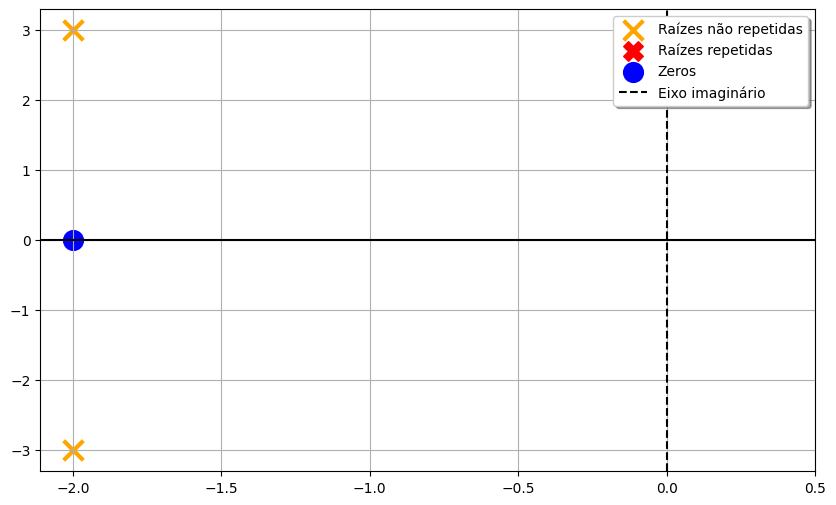

In [7]:
import pimentools as pim

t, s = sp.symbols('t, s')
x = sp.Function('x')(t)

x = sp.Heaviside(t)*sp.exp(-2*t)*sp.cos(3*t)

pim.plota_Laplace(x)